In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics.pairwise import cosine_similarity

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import root_mean_squared_error

In [2]:
FILES_FOLDER = 'Files/'
MATRICES_FOLDER = f'{FILES_FOLDER}Matrices/'

# Data Prep
We will be joining 2 Tables.

`df_VA` contains the Project History of each VA

`USM` containts the Features of an Anime.

## Voice Actor History

We only need the following info since the rest are already present in the Anime table.

1. Anime_ID - To join at
2. Personnel_ID
3. Character_Favorites
4. Role_Main
5. Role_Support

*Note that our Voice Actor records already removed irrelevant character roles (<1 Chracter Favorites)*

In [3]:
df_VA = pd.read_csv(FILES_FOLDER+ 'VA_Raw.csv').drop('Unnamed: 0', axis=1)
print(df_VA.info())

df_VA = df_VA[['Anime_ID', 'Personnel_ID', 'Role_Main', 'Role_Supporting', 'Character_Favorites']] 
df_VA.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 281013 entries, 0 to 281012
Data columns (total 12 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Anime_ID             281013 non-null  int64  
 1   Title                281013 non-null  object 
 2   Type                 280592 non-null  object 
 3   Season               182287 non-null  object 
 4   Year                 280592 non-null  float64
 5   Character            281013 non-null  object 
 6   Character_ID         281013 non-null  int64  
 7   Character_Favorites  281013 non-null  int64  
 8   Personnel_ID         281013 non-null  int64  
 9   Personnel_Name       281013 non-null  object 
 10  Role_Main            281013 non-null  bool   
 11  Role_Supporting      281013 non-null  bool   
dtypes: bool(2), float64(1), int64(4), object(5)
memory usage: 22.0+ MB
None


,Anime_ID,Personnel_ID,Role_Main,Role_Supporting,Character_Favorites
0,3588,10002,False,True,1574
1,27,10002,True,False,974
2,20,10002,False,True,54
3,47,10002,False,True,13
4,523,10002,False,True,25


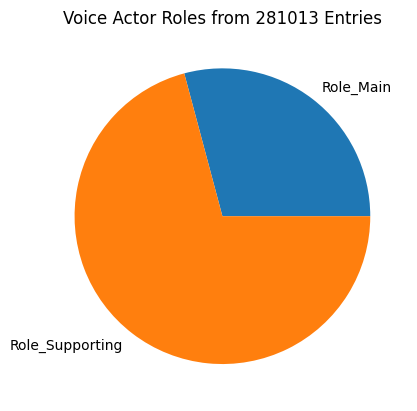

In [4]:
df_VA[['Role_Main', 'Role_Supporting']].sum().plot(kind='pie')
plt.title(f'Voice Actor Roles from {df_VA.shape[0]} Entries')
plt.show()

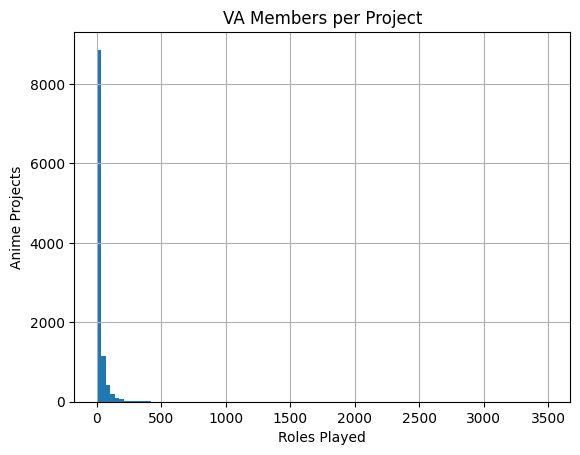

In [5]:
df_VA.Anime_ID.value_counts().hist(bins=100)
plt.title('VA Members per Project')
plt.xlabel('Roles Played')
plt.ylabel('Anime Projects')
plt.show()

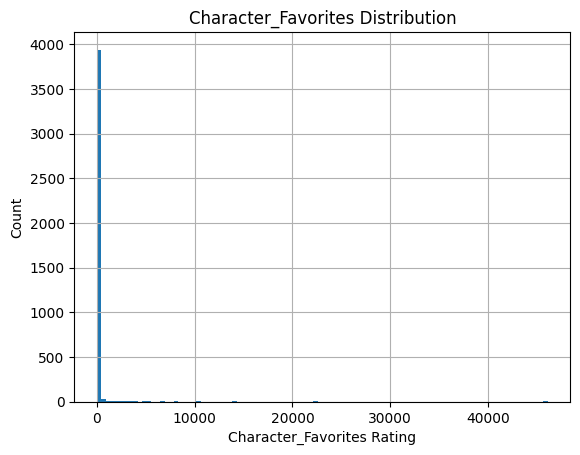

In [6]:
df_VA.Character_Favorites.value_counts().sort_values(ascending=False).hist(bins=100)
plt.title('Character_Favorites Distribution')
plt.xlabel('Character_Favorites Rating')
plt.ylabel('Count')
plt.show()

## Some Cleaning
Our data is heavily skewed to the lower ranges. We need to do some filtering to reduce noise and skew.

We will be using collaborative filtering as well so it's best to avoid sparse data.

### Remove VAs who have Played less than 5 Roles

In [7]:
ID_Filter = df_VA.Personnel_ID.value_counts()
ID_Filter = ID_Filter[ID_Filter < 5]
ID_Filter

Personnel_ID
10015    4
9960     4
5974     4
43301    4
55974    4
        ..
21371    1
9930     1
30513    1
30365    1
9969     1
Name: count, Length: 5328, dtype: int64

In [8]:
df_VA = df_VA[df_VA.Personnel_ID.apply(lambda x: x not in ID_Filter.index)]
df_VA.shape

(270770, 5)

### Remove Unremarkable Anime (Items) 
These are anime projects where the number of liked Chacters is neglible.

In [9]:
ID_Filter = df_VA.Anime_ID.value_counts()
ID_Filter = ID_Filter[ID_Filter < 5]
ID_Filter

Anime_ID
57600    4
30585    4
19575    4
1783     4
8442     4
        ..
1220     1
5785     1
60987    1
37904    1
10104    1
Name: count, Length: 3275, dtype: int64

In [10]:
df_VA = df_VA[df_VA.Anime_ID.apply(lambda x: x not in ID_Filter.index)]
df_VA.shape

(263702, 5)

### Remove Unremarkable Roles Played 
These are anime projects where the number of Character_Favorites is neglible.

In [11]:
ID_Filter = df_VA.Character_Favorites.value_counts()
ID_Filter = ID_Filter[ID_Filter < 100]
ID_Filter

Character_Favorites
395     99
523     99
282     98
437     98
284     98
        ..
4299     1
1401     1
9313     1
2170     1
9718     1
Name: count, Length: 3705, dtype: int64

In [12]:
df_VA = df_VA[df_VA.Character_Favorites.apply(lambda x: x not in ID_Filter.index)]
df_VA.shape

(209752, 5)

## Anime Features

This mostly contains encodings of

1. Genre
2. Theme
3. Source material


Non binary data are
1. Anime Score
2. Members
3. Favorites
4. Year
5. Episodes

In [13]:
USM = pd.read_csv(FILES_FOLDER + 'USM.csv')
USM = USM.loc[~USM.index.duplicated(keep='first')] # Duplicates present from shows continued airing between multiple seasons but still classified as one.
print(USM.info())

USM.head()

<class 'pandas.core.frame.DataFrame'>
Index: 21970 entries, 0 to 21969
Columns: 2593 entries, MAL_id to Episodes
dtypes: float64(2), int64(2590), object(1)
memory usage: 434.8+ MB
None


,MAL_id,Title,Is_Finished,Genre_Action,Genre_Adventure,Genre_Fantasy,Genre_Romance,Genre_Sports,Genre_Horror,Genre_Mystery,...,Source_4-koma manga,Source_Light novel,Source_Manga,Source_Web manga,Score,Members,Favorites,Related_Entries,Year,Episodes
0,249,InuYasha,1,1,1,1,1,0,0,0,...,0,0,1,0,7.87,827227,19338,2,2000,167.0
1,263,Hajime no Ippo,1,0,0,0,0,1,0,0,...,0,0,1,0,8.78,638244,23544,2,2000,75.0
2,1281,Gakkou no Kaidan,1,0,0,0,0,0,1,1,...,0,0,0,0,7.75,233279,2280,0,2000,19.0
3,243,Gravitation,1,0,0,0,0,0,0,0,...,0,0,1,0,6.90,123243,1124,2,2000,13.0
4,180,Vandread,1,1,0,0,0,0,0,0,...,0,0,0,0,7.15,87637,437,4,2000,13.0


# Handle Missing Values

In [14]:
USM.isna().sum().sort_values(ascending=False).head()

Score                           5146
Episodes                        1786
Licensor_Ascendent Animation       0
Licensor_Kadokawa                  0
Licensor_Ponycan USA               0
dtype: int64

Dropping the NaN would be too costly. 

It would consume 1/4 of all entries.

## Median Imputation
Due to the presence of onesided extreme outliers, we will be using Median instead of Mean impute.

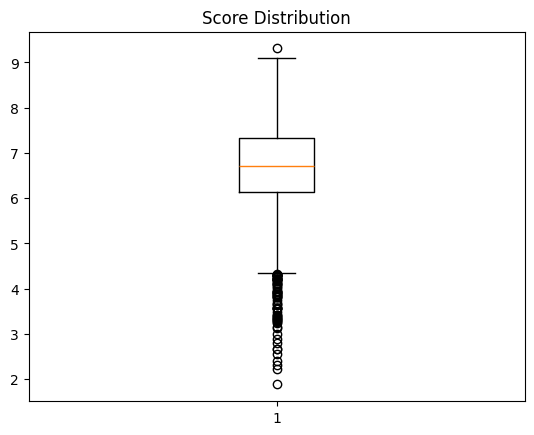

In [15]:
plt.boxplot(USM.Score.dropna())
plt.title('Score Distribution')
plt.show()

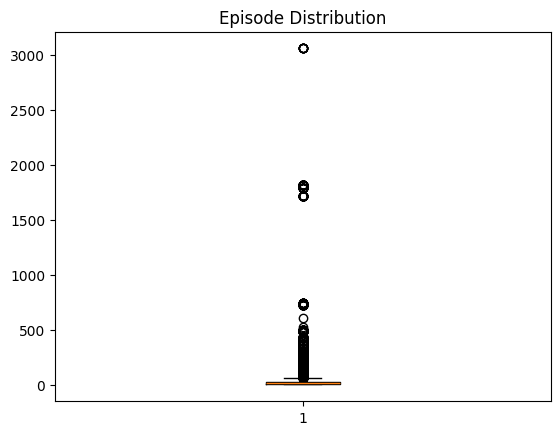

In [16]:
plt.boxplot(USM.Episodes.dropna())
plt.title('Episode Distribution')
plt.show()

In [17]:
print('Score:\t\t',USM.Score.median())
print('Episodes:\t',USM.Episodes.median())

USM.Score = USM.Score.fillna(USM.Score.median())
USM.Episodes = USM.Episodes.fillna(USM.Episodes.median())
USM.describe()

Score:		 6.71
Episodes:	 12.0


,MAL_id,Is_Finished,Genre_Action,Genre_Adventure,Genre_Fantasy,Genre_Romance,Genre_Sports,Genre_Horror,Genre_Mystery,Genre_Supernatural,...,Source_4-koma manga,Source_Light novel,Source_Manga,Source_Web manga,Score,Members,Favorites,Related_Entries,Year,Episodes
count,21970.000000,21970.000000,21970.000000,21970.000000,21970.000000,21970.000000,21970.000000,21970.000000,21970.000000,21970.000000,...,21970.000000,21970.000000,21970.000000,21970.000000,21970.000000,2.197000e+04,21970.000000,21970.000000,21970.000000,21970.000000
mean,27125.252344,0.914201,0.259718,0.198316,0.250114,0.085435,0.034456,0.022258,0.047975,0.070187,...,0.022076,0.050660,0.275512,0.027856,6.729721,9.647500e+04,2616.579563,1.294538,2013.557670,38.075148
std,19058.959933,0.280073,0.438490,0.398740,0.433088,0.279534,0.182402,0.147524,0.213717,0.255467,...,0.146933,0.219307,0.446782,0.164564,0.760164,3.319417e+05,18868.557364,1.240872,6.644739,149.876273
min,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,1.880000,3.500000e+01,0.000000,0.000000,2000.000000,1.000000
25%,7399.750000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,6.340000,6.590000e+02,0.000000,0.000000,2008.000000,2.000000
50%,31132.500000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,6.710000,5.339500e+03,9.000000,2.000000,2014.000000,12.000000
75%,41916.750000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,7.160000,3.990600e+04,116.000000,2.000000,2019.000000,26.000000
max,60826.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,9.310000,4.119103e+06,234852.000000,5.000000,2024.000000,3057.000000


## Lastly Normalize the Ranges to avoid Overpowering Binaries

In [18]:
cols = ['Score', 'Members', 'Favorites', 'Related_Entries', 'Year', 'Episodes']
USM[cols] = MinMaxScaler().fit_transform(USM[cols])
USM.head()

,MAL_id,Title,Is_Finished,Genre_Action,Genre_Adventure,Genre_Fantasy,Genre_Romance,Genre_Sports,Genre_Horror,Genre_Mystery,...,Source_4-koma manga,Source_Light novel,Source_Manga,Source_Web manga,Score,Members,Favorites,Related_Entries,Year,Episodes
0,249,InuYasha,1,1,1,1,1,0,0,0,...,0,0,1,0,0.806191,0.200820,0.082341,0.4,0.0,0.054319
1,263,Hajime no Ippo,1,0,0,0,0,1,0,0,...,0,0,1,0,0.928668,0.154940,0.100250,0.4,0.0,0.024215
2,1281,Gakkou no Kaidan,1,0,0,0,0,0,1,1,...,0,0,0,0,0.790040,0.056625,0.009708,0.0,0.0,0.005890
3,243,Gravitation,1,0,0,0,0,0,0,0,...,0,0,1,0,0.675639,0.029912,0.004786,0.4,0.0,0.003927
4,180,Vandread,1,1,0,0,0,0,0,0,...,0,0,0,0,0.709287,0.021267,0.001861,0.8,0.0,0.003927


# Merge Data
Combines Anime Features with Casting Performance.

Using inner join, missing anime from a cast's work history will be discarded.

## Possible Error Thrown
Our data may be too big, because we OneHot encoded first. The extra dimensionality will affect performance.

If so, either 1. Reverse the OneHot encoding transformation or 2. Continue splicing down the VA list instead (Unspliced join requires 22GB for 1.1 million rows).

Alternatively, load the pkl files instead.

In [19]:
# df_AnimeCastings = pd.merge(USM.rename(columns={'MAL_id':'Anime_ID'}), 
#          df_VA[['Anime_ID', 'Personnel_ID', 'Character_Favorites']], 
#                on='Anime_ID', 
#                how='inner')
# df_AnimeCastings.to_pickle(MATRICES_FOLDER+'X_master.pkl')

# Skip loading since already saved.
df_AnimeCastings = pd.read_pickle(MATRICES_FOLDER+'X_master.pkl')
df_AnimeCastings

,Anime_ID,Title,Is_Finished,Genre_Action,Genre_Adventure,Genre_Fantasy,Genre_Romance,Genre_Sports,Genre_Horror,Genre_Mystery,...,Source_Manga,Source_Web manga,Score,Members,Favorites,Related_Entries,Year,Episodes,Personnel_ID,Character_Favorites
0,249,InuYasha,1,1,1,1,1,0,0,0,...,1,0,0.806191,0.200820,0.082341,0.4,0.0,0.054319,10019,5
1,249,InuYasha,1,1,1,1,1,0,0,0,...,1,0,0.806191,0.200820,0.082341,0.4,0.0,0.054319,1019,17
2,249,InuYasha,1,1,1,1,1,0,0,0,...,1,0,0.806191,0.200820,0.082341,0.4,0.0,0.054319,1034,44
3,249,InuYasha,1,1,1,1,1,0,0,0,...,1,0,0.806191,0.200820,0.082341,0.4,0.0,0.054319,1034,17
4,249,InuYasha,1,1,1,1,1,0,0,0,...,1,0,0.806191,0.200820,0.082341,0.4,0.0,0.054319,10693,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
866498,58606,Girls & Panzer: Saishuushou Part 4 Specials,1,0,0,0,0,0,0,0,...,0,0,0.728129,0.000709,0.000009,0.0,1.0,0.000327,12016,31
866499,58606,Girls & Panzer: Saishuushou Part 4 Specials,1,0,0,0,0,0,0,0,...,0,0,0.728129,0.000709,0.000009,0.0,1.0,0.000327,13,144
866500,58606,Girls & Panzer: Saishuushou Part 4 Specials,1,0,0,0,0,0,0,0,...,0,0,0.728129,0.000709,0.000009,0.0,1.0,0.000327,16323,2
866501,58606,Girls & Panzer: Saishuushou Part 4 Specials,1,0,0,0,0,0,0,0,...,0,0,0.728129,0.000709,0.000009,0.0,1.0,0.000327,247,1


### Free Memory
We desperately need it.

In [20]:
del USM
del df_VA

## Split Data
Note: For this iteration, the goal of splitting data isn't actually to conduct 2 separate tests like in  ML Training. 

But rather it's to mask the known ratings/starred in already.

In [21]:
#X_train, X_test = train_test_split(df_AnimeCastings.drop(columns=['Title']), random_state=42, test_size=0.2)
# X_train.to_pickle(MATRICES_FOLDER + 'X_train_master.pkl')
# X_test.to_pickle(MATRICES_FOLDER + 'X_test_master.pkl')

# Skip loading since already saved.
X_train = pd.read_pickle(MATRICES_FOLDER + 'X_train_master.pkl')
X_test = pd.read_pickle(MATRICES_FOLDER + 'X_test_master.pkl')

print('Train:\t', X_train.shape[0])
print('Test:\t', X_test.shape[0])

Train:	 693202
Test:	 173301


These are the True Positives.

Any other recommendations are mistaken.

In [22]:
Y_test = X_test[['Personnel_ID', 'Anime_ID']].groupby('Personnel_ID').agg(list)
Y_test

,Anime_ID
Personnel_ID,
1,"[8687, 1856, 8687, 10620, 132, 21, 18549, 28, ..."
2,"[37292, 269, 10588, 24405, 940, 34572, 269, 36..."
3,"[37379, 1735, 1565, 34106, 1565, 5114, 235, 21..."
4,"[21, 5030, 6033, 5772, 21, 34927, 21, 6702, 11..."
5,"[1735, 27, 17391, 5684, 19291, 1564, 1735, 173..."
...,...
59797,"[23321, 32902, 32902, 41025, 52955]"
59823,"[269, 21, 1735, 32951, 21, 1735, 21, 269, 1735..."
59826,"[21, 21, 1735, 1735, 21, 1735, 1735, 21, 21, 2..."


In [23]:
X_train = X_train[['Character_Favorites', 'Anime_ID', 'Personnel_ID']]

### Free Memory
We already have the split and truth.

In [24]:
del df_AnimeCastings
del X_test

# Modeling

Now we generate a matrix. 

Users are the Voice Actors, while Items are the Anime Projects.

The value shared is their average Character rankings (if they played multiple characters). 

In [25]:
df_PerformanceScoring = pd.pivot_table(X_train, index='Personnel_ID', columns='Anime_ID', values='Character_Favorites', aggfunc='mean')
df_PerformanceScoring.head()

Anime_ID,5,7,8,15,16,17,18,19,20,21,...,59688,59770,59820,59989,60012,60022,60063,60076,60108,60480
Personnel_ID,,,,,,,,,,,,,,,,,,,,,
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,238.0,...,NaN,NaN,NaN,NaN,142.0,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,15.0,144.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,90.0,...,234.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,49.0,NaN,NaN,NaN,NaN,NaN,7.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Standardize the ratings based on Actor's received ratings.

Big leagues will receive higher Favorites while the lesser known receive less.

So balance it out.

In [26]:
df_PerformanceScoring = df_PerformanceScoring.sub(df_PerformanceScoring.mean(1), axis=0).div(df_PerformanceScoring.std(1), axis=0)

In [27]:
def CalcSparsity(df):
    print('Sparsity: ', np.round(100 * df.notnull().sum().sum() / (df.shape[0] * df.shape[1]), 2), '%')

In [28]:
CalcSparsity(df_PerformanceScoring)

Sparsity:  0.35 %


### High Sparsity
We'll have to keep dropping items until sparsity meets the recommneded 0.5% threshold.

To keep things balanced, both Users and Items must have at least 10 entries each.

In [29]:
CalcSparsity(df_PerformanceScoring.dropna(thresh=10, axis=0).dropna(thresh=10, axis=1))
CalcSparsity(df_PerformanceScoring.dropna(thresh=20, axis=0))
CalcSparsity(df_PerformanceScoring.dropna(thresh=20, axis=1))

df_PerformanceScoring = df_PerformanceScoring.dropna(thresh=10, axis=0).dropna(thresh=10, axis=1)

Sparsity:  0.89 %
Sparsity:  0.86 %
Sparsity:  0.74 %


## Impute
Lastly, we'll fill the missing values with 0 mean.

Thanks to StandardScaler adjusting the values' variance ranges.

In [30]:
df_PerformanceScoring = df_PerformanceScoring.fillna(0)
df_PerformanceScoring

Anime_ID,5,7,8,15,16,17,18,19,20,21,...,58883,58894,59131,59145,59274,59465,59493,59497,59820,59989
Personnel_ID,,,,,,,,,,,,,,,,,,,,,
1,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,-0.379390,0.000000,1.245053,...,0.000000,0.0,0.0,-0.372536,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,-0.240872,1.280194,0.0,0.0,0.000000,0.000000,0.000000,...,-0.193707,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.245665,...,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.063106,0.000000,0.0,0.0,0.000000,0.000000,-0.484594,...,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,...,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59535,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,...,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
59626,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,...,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
59793,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,-0.613438,0.000000,-0.404869,...,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0


# Item-item Filtering

We'll verify first on Anime items.

Similarity in this context means, Anime who have similar cast ratings (Character Favorites).

The reccomendations generated by this would essentially recommend a Project because of similar Casting scores.

In [31]:
df_CastingSimilarity = pd.DataFrame(cosine_similarity(df_PerformanceScoring.T), index=df_PerformanceScoring.columns, columns=df_PerformanceScoring.columns)
df_CastingSimilarity = df_CastingSimilarity.groupby('Anime_ID').sum()
df_CastingSimilarity.head(10)

Anime_ID,5,7,8,15,16,17,18,19,20,21,...,58883,58894,59131,59145,59274,59465,59493,59497,59820,59989
Anime_ID,,,,,,,,,,,,,,,,,,,,,
5,1.000000,0.000000,0.000000,0.003641,-0.000203,0.000000,0.000000,-0.006083,-0.012820,-0.010911,...,0.000000,0.000000,0.000000,0.000000,0.020430,0.000000,0.000000,0.000000,0.000000,0.000000
7,0.000000,1.000000,0.000000,0.002462,0.000000,0.000000,0.000000,0.002846,0.009019,-0.022115,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
8,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.014616,0.000000,0.000000,-0.053486,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.028054,0.000000,0.000000,0.000000,0.000000
15,0.003641,0.002462,0.000000,1.000000,-0.016683,0.006471,0.000000,-0.000232,-0.016961,-0.008949,...,0.001444,0.007180,0.000000,-0.015981,0.000000,0.000000,0.000000,0.006407,0.000000,-0.001870
16,-0.000203,0.000000,0.000000,-0.016683,1.000000,0.000000,0.000000,0.010455,-0.031544,0.042603,...,-0.015671,-0.057452,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.003341
17,0.000000,0.000000,0.000000,0.006471,0.000000,1.000000,0.010318,0.000000,0.025813,0.001533,...,0.000000,0.000000,0.000000,0.006152,0.000000,-0.051053,0.000000,0.000000,0.000000,0.005936
18,0.000000,0.000000,0.014616,0.000000,0.000000,0.010318,1.000000,-0.028174,-0.036843,0.038306,...,0.000000,0.000000,0.000000,0.006727,0.000000,0.005060,0.005464,0.000000,0.000000,0.003363
19,-0.006083,0.002846,0.000000,-0.000232,0.010455,0.000000,-0.028174,1.000000,-0.014836,0.007958,...,0.000000,0.000000,0.000000,0.005340,0.000000,-0.012787,0.000000,0.000000,0.000000,0.001611
20,-0.012820,0.009019,0.000000,-0.016961,-0.031544,0.025813,-0.036843,-0.014836,1.000000,-0.016256,...,-0.003553,0.000826,0.000000,-0.024296,-0.018708,0.010524,0.000000,0.008491,0.000000,-0.014733


### Verify

What to expect?


Try a long running series. They should would share consistent characters, VA cast and thereby personnel ratings.

In [32]:
ANIME_LIST = pd.read_csv(FILES_FOLDER+ 'VA_Raw.csv')[['Anime_ID', 'Title', 'Personnel_ID']].drop_duplicates().groupby(['Anime_ID', 'Title']).agg(list).reset_index().set_index('Anime_ID')

In [33]:
def GetAnimeWithSimilarCastingPerformance(ANIME_ID : np.int64, SIMILARITY_THRESHOLD : float):
    try:
        similar_anime = df_CastingSimilarity.loc[ANIME_ID].sort_values(ascending=False)
        similar_anime = similar_anime[similar_anime.values > SIMILARITY_THRESHOLD]
        
        
        df = pd.concat([ANIME_LIST.loc[similar_anime.index].reset_index(), 
                   pd.Series(similar_anime.values)], 
                  axis=1, 
                  ignore_index=True)
        df.columns = ['Anime_ID', 'Anime_Title', 'Personnel_ID', 'Similarity']
        return df

    
    except Exception as e:
        print('ERROR: ID may not be in training set', e)

#### Mainstream Series

In [34]:
GetAnimeWithSimilarCastingPerformance(16498, SIMILARITY_THRESHOLD = 0.3)

,Anime_ID,Anime_Title,Personnel_ID,Similarity
0,16498,Shingeki no Kyojin,"[10028, 1003, 10065, 10185, 1030, 1047, 1048, ...",1.000000
1,25777,Shingeki no Kyojin Season 2,"[10028, 10065, 1047, 1048, 1057, 10696, 10912,...",0.560958
2,23777,Shingeki no Kyojin Movie 2: Jiyuu no Tsubasa,"[10185, 1047, 1048, 1057, 10668, 10815, 10912,...",0.539379
3,35760,Shingeki no Kyojin Season 3,"[10024, 10028, 10065, 10073, 10185, 1030, 1047...",0.457690
4,23775,Shingeki no Kyojin Movie 1: Guren no Yumiya,"[10028, 10065, 1047, 1048, 1052, 1057, 10701, ...",0.443738
5,18397,Shingeki no Kyojin OVA,"[10065, 1047, 1048, 11030, 11236, 118, 12400, ...",0.441585
6,42091,Shingeki no Kyojin: Chronicle,"[10185, 1030, 1047, 1048, 1052, 1057, 10912, 1...",0.388561
7,31374,Shingeki! Kyojin Chuugakkou,"[10185, 1030, 1047, 1048, 1052, 1057, 10815, 1...",0.381392
8,36702,Shingeki no Kyojin Season 2 Movie: Kakusei no ...,"[10028, 10065, 1047, 1048, 1057, 10696, 10912,...",0.353914
9,25781,Shingeki no Kyojin: Kuinaki Sentaku,"[1047, 1048, 118, 14213, 158, 1602, 212, 22179...",0.349640


#### Niche Series

In [35]:
GetAnimeWithSimilarCastingPerformance(34798, SIMILARITY_THRESHOLD = 0.3)

,Anime_ID,Anime_Title,Personnel_ID,Similarity
0,34798,Yuru Camp△,"[10881, 11184, 12013, 13, 14477, 146, 1472, 15...",1.000000
1,38474,Yuru Camp△ Season 2,"[10881, 11184, 11661, 12013, 13, 14477, 146, 1...",0.589634
2,53410,Yuru Camp△ Season 3,"[10881, 11184, 11661, 12013, 146, 156, 158, 18...",0.442611


#### Theme: Gacha/Vidya Adaptations

In [36]:
GetAnimeWithSimilarCastingPerformance(31418, SIMILARITY_THRESHOLD = 0.2)

,Anime_ID,Anime_Title,Personnel_ID,Similarity
0,31418,KanColle Movie,"[10981, 1105, 11184, 11622, 12452, 13, 14441, ...",1.000000
1,40783,"Shachou, Battle no Jikan desu!","[1047, 14441, 22003, 24269, 28, 31597, 36812, ...",0.335455
2,40504,Major 2nd 2nd Season,"[11622, 11659, 12212, 14441, 17075, 178, 185, ...",0.325120
3,42625,Heion Sedai no Idaten-tachi,"[11787, 14441, 1469, 17, 28755, 287, 28, 34, 6...",0.312207
4,13851,To LOVE-Ru Darkness OVA,"[1133, 124, 132, 13, 141, 156, 185, 207, 215, ...",0.266324
5,41372,Senyoku no Sigrdrifa,"[12750, 25437, 255, 25719, 28, 31597, 33051, 3...",0.265125
6,14967,Boku wa Tomodachi ga Sukunai Next,"[10056, 10943, 11755, 12490, 141, 158, 1762, 1...",0.263443
7,35672,Yama no Susume Third Season,"[10981, 11184, 215, 39009, 57195, 57229, 6625,...",0.255157
8,35759,Sidonia no Kishi: Ai Tsumugu Hoshi,"[100, 11622, 124, 147, 15743, 160, 17793, 1983...",0.230691
9,38853,Ex-Arm,"[10071, 1122, 14441, 18227, 34951, 34, 38359, ...",0.223698


### Observe Negative Similarity

#### Type: OVA Specials

In [37]:
GetAnimeWithSimilarCastingPerformance(6275, SIMILARITY_THRESHOLD = -0.9)

,Anime_ID,Anime_Title,Personnel_ID,Similarity
0,6275,Pokemon Fushigi no Dungeon: Sora no Tankentai ...,"[11, 1286, 1772, 21715, 26961, 320, 500, 55440...",1.000000
1,5256,"Pokemon Fushigi no Dungeon: Toki no Tankentai,...","[10045, 12320, 1233, 1286, 1503, 1517, 21715, ...",0.508470
2,759,Tokyo Godfathers,"[10024, 10037, 10754, 11091, 11101, 11834, 11,...",0.440006
3,6951,Yu☆Gi☆Oh! Movie: Chou Yuugou! Toki wo Koeta Ki...,"[1000, 1052, 12351, 12668, 12669, 13323, 1416,...",0.227937
4,21947,Sore Ike! Anpanman: Gomira no Hoshi,"[10282, 1111, 11, 1237, 1247, 1271, 209, 259, ...",0.150797
...,...,...,...,...
3541,2390,Hoshi no Kirby,"[10023, 10024, 10847, 11908, 11920, 1216, 1236...",-0.135589
3542,1565,Pokemon Diamond & Pearl,"[1000, 10019, 10037, 1024, 1029, 10559, 10664,...",-0.138059
3543,2512,Meitantei Conan OVA 02: 16-nin no Yougisha!?,"[128, 133, 1463, 14, 21, 24, 416, 458, 481, 49...",-0.148745
3544,14293,Nerawareta Gakuen,"[11369, 11662, 1434, 15901, 1762, 185, 212, 27...",-0.154045


## Test For Yourself
Random choice. Refresh as many times as needed.



In [38]:
GetAnimeWithSimilarCastingPerformance(df_CastingSimilarity.sample().index[0], SIMILARITY_THRESHOLD = -0.9)

,Anime_ID,Anime_Title,Personnel_ID,Similarity
0,1619,Negima!? Haru Special!?,"[1053, 10698, 10708, 10710, 10711, 1100, 1101,...",1.000000
1,1732,Negima!? Natsu Special!?,"[1053, 10698, 10708, 10710, 10711, 1100, 1101,...",0.826740
2,1546,Negima!?,"[10516, 1053, 10708, 10710, 1100, 1101, 1102, ...",0.772377
3,157,Mahou Sensei Negima!,"[10011, 10516, 1053, 10708, 10711, 1100, 1101,...",0.531928
4,33478,UQ Holder! Mahou Sensei Negima! 2,"[1003, 1048, 1053, 10701, 10765, 10981, 1100, ...",0.517577
...,...,...,...,...
3541,1509,Mamotte! Lollipop,"[10292, 11289, 1326, 159, 1602, 1650, 172, 189...",-0.247626
3542,146,Kono Minikuku mo Utsukushii Sekai,"[1028, 10607, 11846, 12436, 126, 13, 151, 189,...",-0.259309
3543,1374,Kyoushoku Soukou Guyver (2005),"[10603, 11032, 12118, 12769, 1520, 1667, 176, ...",-0.261825
3544,6166,Asobi ni Iku yo!,"[10013, 10292, 10881, 10943, 14777, 14835, 148...",-0.278658


## Discussion
It works well and reccomends Anime projects that often share a similar cast throughout long series.

Positives are where the casting performed best, while negatives are the same cast at their worst.

More surpising is that it seems to be able to observe certain rules. 

The most similar and most dissimilar (negative) recommendations often lie within the same field. 

Be it theme, media type, or maybe even genre. Most possibly because the Actor specializes in said field but their performance may vary as good or bad according to fan ratings.

This indeed proves why Matrix Factorization can discover Latent Features.

### Notice a problem?
Some reccommendations are numeorous while others are very few when filtering with the threshold.

This would be a cold start issue when no similar reccomendations could be drawn. 

However since we'll be using Top K recommendations, the threshold will be less a concern as long it extracts those with the highest similarity scores.

### Use Case
Item-item filtering in this scenario matches the Performance of the VA Team with the Anime.

Provide it your work history, and it could recommend similar Anime Projects as potential work because of the presence of your previous workmates.

It also tells you, the Team's worst performances in the negatives.

### Continue
However this is merely a verification. 

Seeing that it works, we can proceed to User-User matrices.

# User-User Filtering

We'll return to the original matrix to produce a similarity matrix for users.

Similarity in this context means, Actors who have been in the same project with similar ratings (Character Favorites). 

In [39]:
df_Collabs = pd.DataFrame(cosine_similarity(df_PerformanceScoring), index=df_PerformanceScoring.index, columns=df_PerformanceScoring.index)
df_Collabs.head(10)

Personnel_ID,1,2,3,4,5,6,8,9,10,11,...,59428,59464,59466,59476,59534,59535,59626,59793,59797,59823
Personnel_ID,,,,,,,,,,,,,,,,,,,,,
1,1.000000,-0.019853,0.011136,-0.004009,-0.016653,-0.001324,-0.008956,-0.041569,0.002001,0.001829,...,0.0,0.000000,-0.000128,0.000000,-0.022838,-0.008372,-0.007834,-0.001440,0.000000,-0.013958
2,-0.019853,1.000000,-0.033169,0.006039,0.004573,0.016564,0.015999,0.103763,0.083141,-0.012587,...,0.0,0.000000,0.000480,0.001514,-0.000774,0.006784,0.000000,0.003342,-0.000718,-0.010107
3,0.011136,-0.033169,1.000000,0.002076,-0.009602,0.006412,-0.003325,0.001922,0.007105,0.052417,...,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.021287,0.000000,-0.064727
4,-0.004009,0.006039,0.002076,1.000000,-0.001148,0.236193,0.002655,0.002988,0.001843,0.088562,...,0.0,0.000000,0.000000,-0.000588,0.011107,0.004072,0.000000,0.002810,0.000000,0.008697
5,-0.016653,0.004573,-0.009602,-0.001148,1.000000,0.004427,0.044147,0.110963,-0.014326,0.002761,...,0.0,0.000000,0.000000,-0.001448,0.000210,0.000000,0.000000,-0.005422,0.013898,-0.013402
6,-0.001324,0.016564,0.006412,0.236193,0.004427,1.000000,0.162134,-0.014170,-0.037349,0.040256,...,0.0,0.000000,0.004310,-0.000809,-0.009330,0.000000,0.000000,0.120218,-0.000198,0.575993
8,-0.008956,0.015999,-0.003325,0.002655,0.044147,0.162134,1.000000,0.000686,0.003216,-0.015317,...,0.0,-0.007703,0.002785,0.000000,0.000000,0.000000,0.000000,0.001570,-0.028112,0.014228
9,-0.041569,0.103763,0.001922,0.002988,0.110963,-0.014170,0.000686,1.000000,0.127770,0.001650,...,0.0,0.001224,0.000000,-0.001029,0.000000,0.000000,0.006888,-0.007455,0.001172,-0.018876
10,0.002001,0.083141,0.007105,0.001843,-0.014326,-0.037349,0.003216,0.127770,1.000000,0.003836,...,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,-0.013437,0.001234,0.000000,-0.053569


In [40]:
PERSONNEL_LIST = pd.read_csv(FILES_FOLDER+ 'VA_Raw.csv')[['Personnel_ID', 'Personnel_Name', 'Title', 'Character', 'Anime_ID']].groupby(['Personnel_ID', 'Personnel_Name']).agg(list)

In [41]:
def GetMostSimilarUsersAndProject(PERSONNEL_ID : np.uint, K : np.uint = 10 ):
    ALREADY_CASTED = df_PerformanceScoring.loc[PERSONNEL_ID] != 0
    
    
    df = pd.DataFrame()
    df[['Similar_Personnel', 'Personnel_Similarity']] = df_Collabs.loc[PERSONNEL_ID].sort_values(ascending=False)[1:K+1].reset_index()
    
    df['Shared_Projects'] = [
        sum(1 for a, b in zip(df_PerformanceScoring.loc[PERSONNEL_ID], df_PerformanceScoring.loc[ID]) if a != 0 and b != 0)
        for ID in df.Similar_Personnel
    ]

    df[['Recommended_Similar_Actors_Project', 'Project_Character_Favorites']] = df_PerformanceScoring.loc[df.Similar_Personnel, ~ALREADY_CASTED].mean().sort_values(ascending=False).head(K).reset_index()
    df['Is_Casted(Y)'] = [1 if x in Y_test.loc[PERSONNEL_ID].Anime_ID else 0 for x in df.Recommended_Similar_Actors_Project]
    
    
    print({
        'Total' : df.shape[0],
        'True_Positive': len(set(df.Recommended_Similar_Actors_Project) & set(Y_test.loc[PERSONNEL_ID].Anime_ID))
    })

    return df

In [42]:
def GetPersonnelFromColabs(PERSONNEL_ID : np.int64, SIMILARITY_THRESHOLD : float):
    try:
        similar_personnel = df_Collabs.loc[PERSONNEL_ID].sort_values(ascending=False)
        similar_personnel = similar_personnel[similar_personnel.values > SIMILARITY_THRESHOLD]
        
        
        df = pd.concat([PERSONNEL_LIST.loc[similar_personnel.index].reset_index(), 
                   pd.Series(similar_personnel.values)], 
                  axis=1, 
                  ignore_index=True)
        df.columns = ['Personnel_ID', 'Personnel_Name', 'Projects', 'Character', 'Anime_ID', 'Similarity']
        return df

    except Exception as e:
        print('ERROR: ID may not be in training set', e)

In [43]:
GetMostSimilarUsersAndProject(PERSONNEL_ID = 21, K = 10)

{'Total': 10, 'True_Positive': 0}


,Similar_Personnel,Personnel_Similarity,Shared_Projects,Recommended_Similar_Actors_Project,Project_Character_Favorites,Is_Casted(Y)
0,9867,0.898356,2,44516,0.134577,0
1,995,0.887409,4,49785,0.096878,0
2,1482,0.883869,1,40834,0.076654,0
3,8022,0.877244,2,52657,0.076654,0
4,510,0.872491,3,1683,0.075493,0
5,50531,0.868262,2,44200,0.058061,0
6,1452,0.858758,2,49114,0.053119,0
7,12402,0.851956,2,20031,0.036648,0
8,43093,0.832966,1,1132,0.026539,0
9,50839,0.825961,1,969,0.026100,0


In [44]:
GetPersonnelFromColabs(PERSONNEL_ID = 21, SIMILARITY_THRESHOLD = 0.8)

,Personnel_ID,Personnel_Name,Projects,Character,Anime_ID,Similarity
0,21,Inoue Kazuhiko,"[Natsume Yuujinchou Shichi Special, Akuyaku Re...","[Madara, Tondabayashi, Kenzaburou, Madara, Jen...","[60302, 57719, 55823, 58714, 59131, 58488, 497...",1.000000
1,9867,Jenkins Bill,[Shingeki no Kyojin: The Final Season - Kanket...,"[Leonhart, Father, Popuko, Yoroi Musha, Narrat...","[51535, 50663, 49918, 50410, 48895, 48583, 484...",0.898356
2,995,Hikami Kyouko,"[Reiwa no Di Gi Charat, Poputepipikku 2nd Seas...","[Usada, Hikaru, Pipimi, A37, Erika, Erika, Aps...","[49179, 50663, 39728, 40351, 34540, 4214, 2216...",0.887409
3,1482,Shiina Hekiru,"[Yoru no Kurage wa Oyogenai, Girls & Panzer: S...","[Honami, Chouno, Ami, Yohane's Mother, Pipimi,...","[54839, 39167, 52214, 50663, 50273, 39166, 416...",0.883869
4,8022,Ugaki Hidenari,"[Hikikomari Kyuuketsuki no Monmon, Tensei Kizo...","[Heaven, Helldeus, Esfort, Rex Terra, Pipimi, ...","[54103, 52608, 50663, 51347, 26055, 10702, 996...",0.877244
5,510,Lau Gwendolyn,"[Poputepipikku 2nd Season, One Piece Film: Red...","[Popuko, Makino, Olminu, Amada, Minami, Amada,...","[50663, 50410, 31339, 13331, 12413, 6702, 7902...",0.872491
6,50531,Strange Ciarán,"[Kusuriya no Hitorigoto 2nd Season, Kimi wa Me...","[Pairin, Yamashita, Kobachi, Souma, Alice, McM...","[58514, 57611, 54284, 55855, 52196, 53434, 535...",0.868262
7,1452,Mizushima Yuu,"[Poputepipikku 2nd Season, One Piece Film: Red...","[Pipimi, Zeus, Chapelle, Roland, Chapelle, Rol...","[50663, 50410, 35788, 32282, 32608, 28171, 225...",0.858758
8,12402,Douglas DC,"[NieR:Automata Ver1.1a Part 2, NieR:Automata V...","[Pod 042, Pod 042, Albarea, Rufus , X, Drake, ...","[56063, 51105, 48441, 53890, 49784, 50663, 507...",0.851956
9,43093,Kunda Gabe,"[Shangri-La Frontier: Kusoge Hunter, Kamige ni...","[Professor, Pantherlily, Takagi, Ken, Professo...","[58572, 49785, 54789, 52347, 54856, 52657, 531...",0.832966


In [45]:
GetPersonnelFromColabs(PERSONNEL_ID = 160, SIMILARITY_THRESHOLD = 0.3)

,Personnel_ID,Personnel_Name,Projects,Character,Anime_ID,Similarity
0,160,Koyasu Takehito,"[3-nen Z-gumi Ginpachi-sensei, Jujutsu Kaisen:...","[Takasugi, Shinsuke, Fushiguro, Touji, Shindou...","[54757, 59654, 49363, 58473, 59571, 57559, 587...",1.000000
1,54,Endou Aya,"[Jigoku Sensei Nube (2025), Jujutsu Kaisen: Ka...","[Takahashi, Ritsuko, Ieiri, Shouko, Totoki, Ui...","[59342, 59654, 55995, 48418, 52196, 52196, 561...",0.483478
2,42598,El Kammouchi Karim,"[Hanma Baki vs. Kengan Ashura, Kekkon Yubiwa M...","[Hanma, Baki, Gisaras, Marmarugias, Chuhlhourn...","[58510, 54265, 53998, 54856, 46569, 50631, 536...",0.472007
3,25609,Aflalo Esther,"[Maou 2099, Seirei Gensouki 2, Amagami-san Chi...","[Rosanta, Mag, Claire, Celia, Anekouji, Mahiru...","[54853, 50306, 55071, 53580, 53580, 58592, 506...",0.438198
4,21393,Basecqz Julie,"[Isekai wa Smartphone to Tomo ni. 2, Pokemon: ...","[Silhoueska, Elze, Junsa, Junsa, Pochama, Baud...","[51632, 53874, 50673, 50673, 37987, 41439, 403...",0.425489
5,45662,Maire Laura,"[Watashi no Shiawase na Kekkon, Spy Kyoushitsu...","[Saimori, Miyo, Monika, Yue, Yue, Kamui, Kanna...","[51552, 51252, 51473, 50916, 49893, 40507, 536...",0.413083
6,56300,Guidi Niccolò,"[Violet Evergarden: Recollections, Blue Period...","[Hodgins, Claudia, Sumida, Gloxinia, Hodgins, ...","[53672, 46352, 41491, 37987, 38668, 39701, 397...",0.399307
7,1111,Sakuma Rei,"[Ranma ½ (2024), Nakitai Watashi wa Neko wo Ka...","[Shampoo, Tamaki, Pipimi, Molly, Batako-san, B...","[59145, 41168, 37596, 35062, 23617, 18355, 183...",0.390699
8,634,Akimoto Yousuke,"[Uzaki-chan wa Asobitai! Double, Kuro no Shouk...","[Asai, Akihiko, Gerard, Asai, Akihiko, Ubertin...","[42962, 51064, 41226, 40128, 40256, 37596, 947...",0.389892
9,43662,Guimarães Tiaggo,"[Kimi to Boku no Saigo no Senjou, Aruiwa Sekai...","[Salinger, Edward, Fia Arclight, Chris, Ruthve...","[49981, 49782, 50461, 49114, 48580, 43439, 405...",0.380077


In [46]:
GetMostSimilarUsersAndProject(PERSONNEL_ID = 160, K = 10)

{'Total': 10, 'True_Positive': 1}


,Similar_Personnel,Personnel_Similarity,Shared_Projects,Recommended_Similar_Actors_Project,Project_Character_Favorites,Is_Casted(Y)
0,54,0.483478,18,10808,0.341388,0
1,42598,0.472007,6,147,0.339187,0
2,25609,0.438198,5,39576,0.200675,0
3,21393,0.425489,10,37349,0.168734,0
4,45662,0.413083,6,38234,0.159551,0
5,56300,0.399307,4,9355,0.151589,0
6,1111,0.390699,6,5277,0.151589,0
7,634,0.389892,5,927,0.147421,0
8,43662,0.380077,7,16870,0.128120,0
9,157,0.370944,13,28927,0.118865,1


## Why such low scores?

Note that our K is set to generate Top 10 predictions, but look at our Truths.

Many have less than K correct answers.

In short our testing is meaningless because the correct answers are too little.

In [47]:
Y_test.Anime_ID.apply(len).min()

np.int64(1)

We'll remedy this by returning to our dataset and being stricter.

### Regenerate the Records but Filter to Actors reqquiring threshold projects taken
Only consider the Actors with more than 100 noteworthy projects completed.

### Preprocessing Oversights
The mistake made was failing to count only the unique. 

This would affect our filtering if not catched.

```python
# Still over 800k entries
total_ProjectsTaken = df_AnimeCastings[['Personnel_ID', 'Anime_ID']].groupby('Personnel_ID').agg(list)

# 140k entries
total_ProjectsTaken = df_AnimeCastings[['Personnel_ID', 'Anime_ID']].groupby('Personnel_ID').agg(set)
```

#### Train Test Split
Additionally, stratify the split so it's proportional between Train and Test.

In [48]:
# scaler = StandardScaler()
# df_AnimeCastings = pd.read_pickle(MATRICES_FOLDER+'X_master.pkl')

# total_ProjectsTaken = df_AnimeCastings[['Personnel_ID', 'Anime_ID']].groupby('Personnel_ID').agg(set)
# total_ProjectsTaken = total_ProjectsTaken[total_ProjectsTaken.Anime_ID.apply(lambda x : len(x) > 100)]
# df_AnimeCastings = df_AnimeCastings[df_AnimeCastings.Personnel_ID.apply(lambda x : x in total_ProjectsTaken.index)]
# df_AnimeCastings['STD_Character_Favorites'] = df_AnimeCastings[['Personnel_ID', 'Character_Favorites']].groupby('Personnel_ID')['Character_Favorites'].transform(lambda x: scaler.fit_transform(x.values.reshape(-1, 1)).flatten())

# df_AnimeCastings.to_pickle(MATRICES_FOLDER+'X_100roles.pkl')
# df_AnimeCastings

# X_train, X_test = train_test_split(df_AnimeCastings, random_state=42, test_size=0.2, stratify=df_AnimeCastings['Personnel_ID'])

# del df_AnimeCastings

# X_train.to_pickle(MATRICES_FOLDER + 'X_train_100roles.pkl')
# X_test.to_pickle(MATRICES_FOLDER + 'X_test_100roles.pkl')


X_train = pd.read_pickle(MATRICES_FOLDER + 'X_train_100roles.pkl')
X_test  = pd.read_pickle(MATRICES_FOLDER + 'X_test_100roles.pkl')

print('Train:\t', X_train.shape[0])
print('Test:\t', X_test.shape[0])

Train:	 112722
Test:	 28181


In [49]:
X_train = X_train[['Anime_ID', 'Personnel_ID', 'Character_Favorites', 'STD_Character_Favorites']]
X_test = X_test[['Anime_ID', 'Personnel_ID', 'Character_Favorites', 'STD_Character_Favorites']]

Extract the Y truths.

In [50]:
Y_train = X_train[['Personnel_ID', 'Anime_ID', 'Character_Favorites', 'STD_Character_Favorites']].groupby(['Personnel_ID', 'Anime_ID']).mean()
Y_train

Y_test = X_test[['Personnel_ID', 'Anime_ID', 'Character_Favorites', 'STD_Character_Favorites']].groupby(['Personnel_ID', 'Anime_ID']).mean()
Y_test

Character_Favorites  STD_Character_Favorites
Personnel_ID Anime_ID                                              
1            21                      238.0                 1.362719
             28                       88.0                 0.109711
             93                       62.0                -0.107478
             98                       13.0                -0.516794
             104                       4.0                -0.591974
...                                    ...                      ...
42373        49785                     7.0                -0.330049
             52635                     1.0                -0.430903
             52955                     2.0                -0.414094
             53446                     1.0                -0.430903
             54789                    10.0                -0.279622

[13247 rows x 2 columns]

### Top K = 20

In [51]:
X_test[['Personnel_ID', 'Anime_ID']].groupby('Personnel_ID').agg(set).Anime_ID.apply(len).min()

np.int64(20)

In [52]:
del X_test

In [53]:
df_PerformanceScoring = pd.pivot_table(X_train, index='Personnel_ID', columns='Anime_ID', values='STD_Character_Favorites', aggfunc='mean')
del X_train

CalcSparsity(df_PerformanceScoring)
df_PerformanceScoring = df_PerformanceScoring.fillna(0)

df_Collabs = pd.DataFrame(cosine_similarity(df_PerformanceScoring), index=df_PerformanceScoring.index, columns=df_PerformanceScoring.index)
df_Collabs.head(10)

Sparsity:  2.46 %


Personnel_ID,1,2,3,4,5,6,8,9,10,11,...,33051,33995,34209,34785,34855,36888,36895,38428,38659,42373
Personnel_ID,,,,,,,,,,,,,,,,,,,,,
1,1.000000,-0.015703,0.015518,-0.003026,-0.023198,-0.004463,-0.000085,-0.010255,0.000431,0.000000,...,0.001926,0.002078,0.005808,0.004743,-0.000311,-0.016485,-0.000757,-0.001757,-0.001814,0.013716
2,-0.015703,1.000000,-0.032051,0.002992,-0.000142,0.031376,0.003789,0.096778,0.252618,-0.000966,...,0.141800,-0.000763,0.028674,0.001963,-0.002876,0.000492,0.000397,-0.002766,0.000773,0.103322
3,0.015518,-0.032051,1.000000,0.002346,-0.011326,-0.012472,-0.000191,-0.010377,0.004653,0.063317,...,0.018734,0.000000,0.000000,0.000000,-0.053851,-0.000152,0.001617,0.001957,-0.000039,-0.001158
4,-0.003026,0.002992,0.002346,1.000000,-0.003025,-0.006844,0.010275,0.000269,0.000711,0.001293,...,0.004551,0.000000,0.000000,0.001379,0.000308,0.001401,-0.000511,0.002054,0.000910,0.000167
5,-0.023198,-0.000142,-0.011326,-0.003025,1.000000,0.016050,0.012481,0.065922,-0.003182,-0.000767,...,-0.008414,0.002969,-0.017012,0.008408,0.002843,0.012416,0.003607,-0.000410,-0.001714,0.003040
6,-0.004463,0.031376,-0.012472,-0.006844,0.016050,1.000000,0.072394,-0.001943,-0.018190,0.061520,...,0.007142,0.147755,0.017326,0.000000,0.103026,0.003523,-0.001756,0.205342,0.002167,0.003342
8,-0.000085,0.003789,-0.000191,0.010275,0.012481,0.072394,1.000000,-0.002043,-0.000473,0.031081,...,-0.002205,0.082746,0.030620,0.000906,0.057408,-0.001625,-0.002320,0.116675,-0.000233,0.012127
9,-0.010255,0.096778,-0.010377,0.000269,0.065922,-0.001943,-0.002043,1.000000,0.125337,-0.006685,...,0.295076,0.001149,-0.003782,0.001579,0.000974,0.027622,-0.009904,-0.000342,-0.001922,0.243807
10,0.000431,0.252618,0.004653,0.000711,-0.003182,-0.018190,-0.000473,0.125337,1.000000,0.001216,...,0.210544,-0.017924,-0.035637,0.002385,0.000000,-0.004836,0.001245,-0.002203,0.000000,0.173764


Look at the Sparsity improvement.
No additional dropping needed

When Evaluating on Train, we are comparing with those already Casted in.

When Evaluating on Test, we are comparing with those hidden Casteings.

In [54]:
def Evaluate(PERSONNEL_ID : np.uint, K_SimilarActors : np.uint = 10, K_RecommendedProjects : np.uint = 20):
    df = pd.DataFrame()
    
    # Find the most similar actors, excluding self
    similarVA = df_Collabs.loc[PERSONNEL_ID].sort_values(ascending=False)[1:K_SimilarActors+1]

    # Reccomend the their highest rated project performances
    recommendations  = df_PerformanceScoring.loc[similarVA.index].sum().sort_values(ascending=False).head(K_RecommendedProjects)


    # Visual output
    df = pd.concat([similarVA.reset_index(), recommendations.reset_index()], axis=1, ignore_index=True)
    #df.columns = ['Personnel_ID', 'Personnel_Similarity', 'Anime_ID', 'Avg_Favorites']
    df.columns = ['Personnel_ID', 'Personnel_Similarity', 'Anime_ID', 'Avg_Favorites']

    
    df['Is_Casted(Y_train)'] = df['Anime_ID'].apply(lambda x : x in Y_train.loc[PERSONNEL_ID].index)
    df['Is_Casted(Y_test)'] = df['Anime_ID'].apply(lambda x : x in Y_test.loc[PERSONNEL_ID].index)

    print('Train')
    print('True Positives: ', df['Is_Casted(Y_train)'].sum(), '/', K_RecommendedProjects, '\nPrecision: \t', df['Is_Casted(Y_train)'][:K_RecommendedProjects].mean())
    print('Test')
    print('True Positives: ', df['Is_Casted(Y_test)'].sum(), '/', K_RecommendedProjects, '\nPrecision: \t', df['Is_Casted(Y_test)'][:K_RecommendedProjects].mean())
    return df

Reccomend 20 from the Single Most Similar Actor (Excluding self)

In [55]:
Evaluate(6, 1, 20).head(10)

Train
True Positives:  5 / 20 
Precision: 	 0.25
Test
True Positives:  3 / 20 
Precision: 	 0.15


,Personnel_ID,Personnel_Similarity,Anime_ID,Avg_Favorites,Is_Casted(Y_train),Is_Casted(Y_test)
0,1239.0,0.380691,1735,3.106718,True,True
1,NaN,NaN,16870,3.106718,False,False
2,NaN,NaN,20,3.106718,True,True
3,NaN,NaN,516,1.260175,False,False
4,NaN,NaN,38691,1.044205,False,False
5,NaN,NaN,48549,1.044205,False,False
6,NaN,NaN,34866,0.547474,False,False
7,NaN,NaN,24833,0.439489,False,False
8,NaN,NaN,30654,0.439489,False,False
9,NaN,NaN,34389,0.439489,False,False


Increase the pool to 10 most similar actors.

In [56]:
Evaluate(6, 10, 20).head(10)

Train
True Positives:  4 / 20 
Precision: 	 0.2
Test
True Positives:  2 / 20 
Precision: 	 0.1


,Personnel_ID,Personnel_Similarity,Anime_ID,Avg_Favorites,Is_Casted(Y_train),Is_Casted(Y_test)
0,1239.0,0.380691,50663,74.724168,True,False
1,262.0,0.273842,1735,9.797861,True,True
2,31597.0,0.223727,20,9.782791,True,True
3,38428.0,0.205342,5690,7.553076,False,False
4,1547.0,0.200838,16870,5.544681,False,False
5,97.0,0.194163,13667,5.047666,False,False
6,257.0,0.192900,37259,4.880029,False,False
7,62.0,0.189595,7785,4.840975,False,False
8,157.0,0.182065,34537,4.840975,False,False
9,599.0,0.178993,42203,4.837640,False,False


Top 20 Reccomendations from the 5 Most Similar Actors.

In [57]:
Evaluate(160, 5, 20).head(10)

Train
True Positives:  2 / 20 
Precision: 	 0.1
Test
True Positives:  1 / 20 
Precision: 	 0.05


,Personnel_ID,Personnel_Similarity,Anime_ID,Avg_Favorites,Is_Casted(Y_train),Is_Casted(Y_test)
0,112.0,0.291950,37596,53.521309,True,False
1,27.0,0.287825,36976,5.576513,False,False
2,16641.0,0.268110,52093,4.846702,False,False
3,195.0,0.261159,32212,4.535250,False,False
4,30.0,0.226407,14837,3.986031,False,False
5,NaN,NaN,25389,3.986031,False,False
6,NaN,NaN,55690,3.975573,False,False
7,NaN,NaN,52578,3.975573,False,False
8,NaN,NaN,26349,3.949328,False,False
9,NaN,NaN,50631,3.786267,False,False


Try murking the results. 

Get everyone's opinion.

In [58]:
Evaluate(3, 1500, 100).head(10)

Train
True Positives:  8 / 100 
Precision: 	 0.08
Test
True Positives:  1 / 100 
Precision: 	 0.01


,Personnel_ID,Personnel_Similarity,Anime_ID,Avg_Favorites,Is_Casted(Y_train),Is_Casted(Y_test)
0,84,0.212511,35330.0,263.480589,False,False
1,475,0.169228,37596.0,170.267742,False,False
2,1154,0.109776,50663.0,158.448712,False,False
3,152,0.103694,56894.0,41.890284,False,False
4,337,0.085669,49040.0,35.018860,False,False
5,21,0.065495,38408.0,34.872823,False,False
6,11,0.063317,54789.0,32.368320,False,False
7,348,0.053663,18429.0,32.212817,False,False
8,278,0.047252,51716.0,32.194139,False,False
9,414,0.044662,31964.0,32.056115,False,False


Try going over the limited

Increase recommendations over truths. 

500 recommendations from the 50 most similar actors.

In [59]:
Evaluate(1, 50, 500).head(10)

Train
True Positives:  32 / 500 
Precision: 	 0.064
Test
True Positives:  8 / 500 
Precision: 	 0.016


,Personnel_ID,Personnel_Similarity,Anime_ID,Avg_Favorites,Is_Casted(Y_train),Is_Casted(Y_test)
0,262.0,0.187078,37596,166.498427,True,False
1,112.0,0.173717,35330,50.250019,False,False
2,195.0,0.169267,50663,39.138724,False,False
3,27.0,0.160403,36511,13.139116,False,False
4,16641.0,0.159177,27899,12.198880,False,False
5,1547.0,0.148594,37510,11.254851,False,False
6,1154.0,0.136924,18429,11.154010,False,False
7,30.0,0.135421,21075,10.739056,False,False
8,52.0,0.132073,13663,9.122519,False,False
9,17.0,0.124595,54042,8.859422,False,False


In [60]:
def EvaluateScores(PERSONNEL_ID : np.uint, K_SimilarActors : np.uint = 10, K_RecommendedProjects : np.uint = 20):
    # Find the most similar actors, excluding self
    similarVA = df_Collabs.loc[PERSONNEL_ID].sort_values(ascending=False)[1:K_SimilarActors+1]

    # Reccomend the their highest rated project performances
    recommendations  = df_PerformanceScoring.loc[similarVA.index].sum().sort_values(ascending=False).head(K_RecommendedProjects).reset_index()

    my_projects = set(df_PerformanceScoring.loc[PERSONNEL_ID, df_PerformanceScoring.loc[PERSONNEL_ID] != 0].index)

    shared_Projects = 0
    for ID in similarVA.index:
        shared_Projects += len(my_projects.intersection(set(df_PerformanceScoring.loc[ID, df_PerformanceScoring.loc[ID] !=0].index)))
    
    train_pred = recommendations.iloc[:,0].apply(lambda x : x in Y_train.loc[PERSONNEL_ID].index)
    test_pred = recommendations.iloc[:,0].apply(lambda x : x in Y_test.loc[PERSONNEL_ID].index)

    return {
        'Personnel_ID' : PERSONNEL_ID,
        'K_SimilarActors' : K_SimilarActors,
        'Total_SharedProjects' : shared_Projects,
        'K_Reccomendations' : K_RecommendedProjects,
        'True_Positive(Train)' : train_pred.sum(),
        'Precision(Train)' : train_pred[:K_RecommendedProjects].mean(),
        'True_Positive(Test)' : test_pred.sum(),
        'Precision(Test)' : test_pred[:K_RecommendedProjects].mean(),
    }

### Refine
The hyperparameter is K_SimilarActors

What we might expect is that as you get more opinions, the murkier the reccoemndations will get.

This because you're getting opinions from less similar personnel already. What maybe your best performances might their worst.

In [61]:
# scores = []
# for ACTOR in df_Collabs.index:
#     for K_ACTORS in np.arange(1, 20):
#         for K_REC in np.arange(10,51,10):
#             scores.append(EvaluateScores(ACTOR,K_ACTORS,K_REC))
# scores = pd.DataFrame(scores)
# scores.to_csv('Scores/UserUserPrecision.csv')

scores = pd.read_csv('Scores/UserUserPrecision.csv')

### Best K Hyperparameters?

In [62]:
scores.loc[scores[['Precision(Train)', 'Precision(Test)']].mean(axis=1).sort_values(ascending=False).head(10).index]

,Unnamed: 0,Personnel_ID,K_SimilarActors,Total_SharedProjects,K_Reccomendations,True_Positive(Train),Precision(Train),True_Positive(Test),Precision(Test)
10660,10660,253,5,203,10,10,1.0,7,0.7
10700,10700,253,13,363,10,10,1.0,7,0.7
10680,10680,253,9,274,10,10,1.0,7,0.7
10670,10670,253,7,250,10,10,1.0,7,0.7
10705,10705,253,14,381,10,10,1.0,7,0.7
10650,10650,253,3,122,10,10,1.0,7,0.7
10690,10690,253,11,324,10,10,1.0,7,0.7
10685,10685,253,10,282,10,10,1.0,7,0.7
10655,10655,253,4,142,10,10,1.0,7,0.7
10665,10665,253,6,239,10,10,1.0,7,0.7


These seem to be more of a overfit with high Train but low Test.

In [63]:
scores[['Precision(Train)', 'Precision(Test)']].mean()

Precision(Train)    0.250955
Precision(Test)     0.077848
dtype: float64

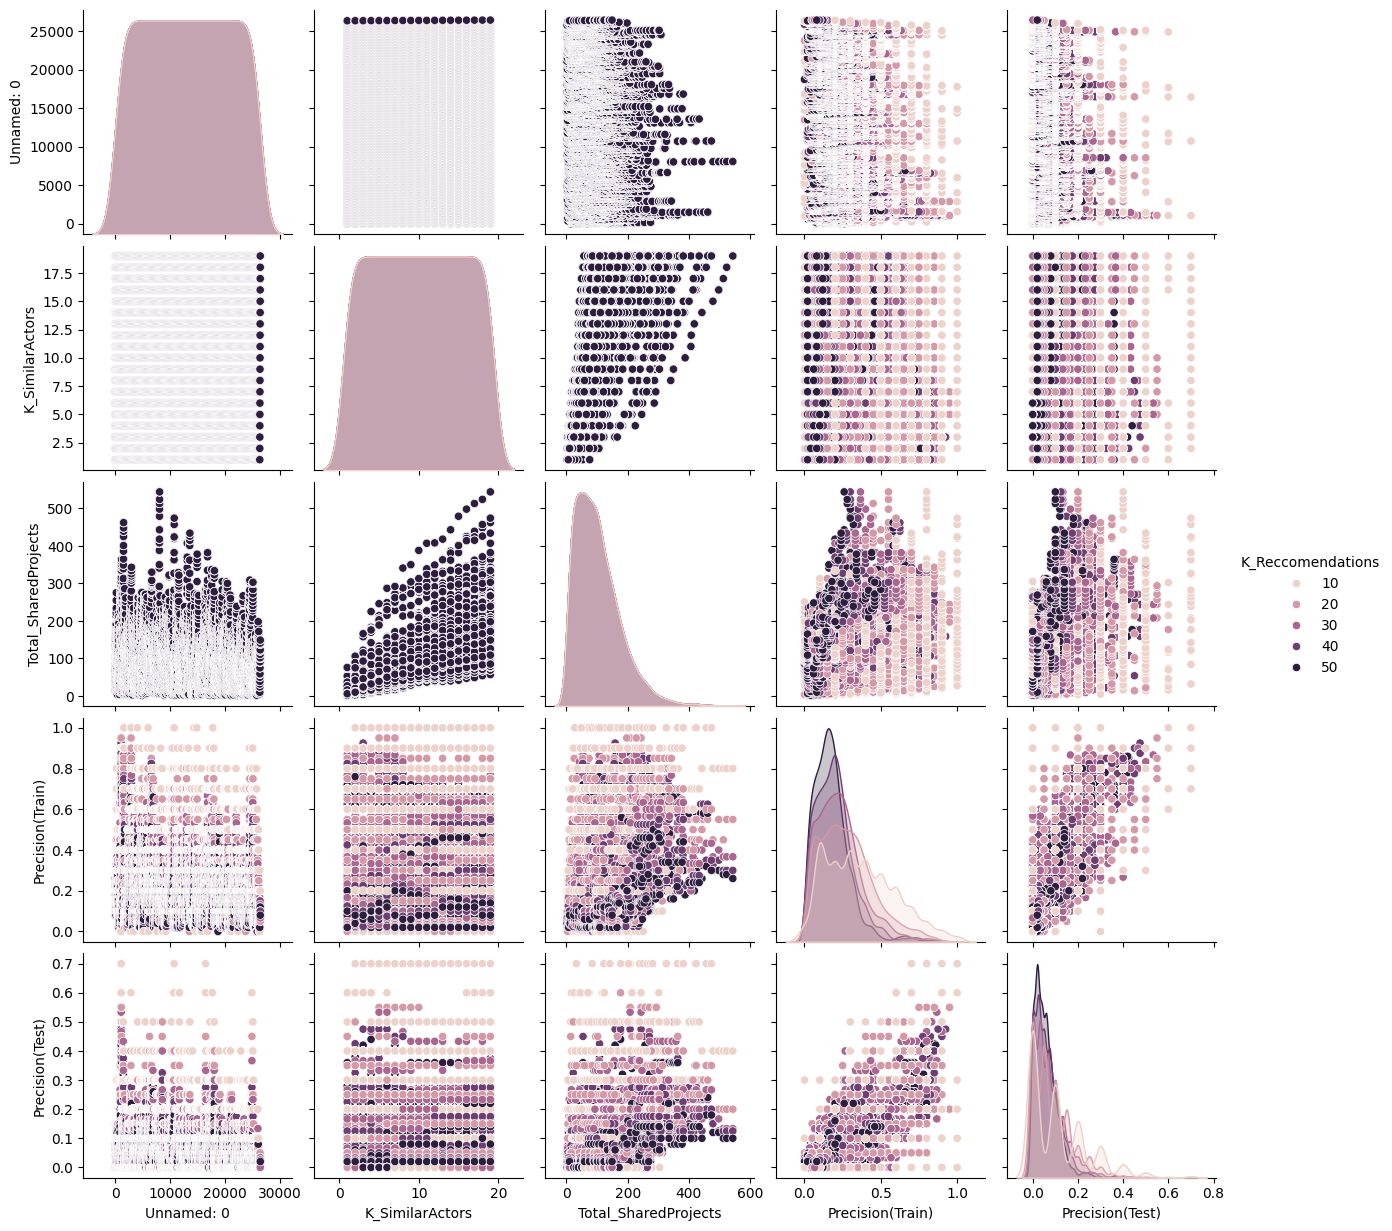

In [64]:
sns.pairplot(scores.drop(columns=['Personnel_ID', 'True_Positive(Train)', 'True_Positive(Test)']), hue='K_Reccomendations')
plt.show()

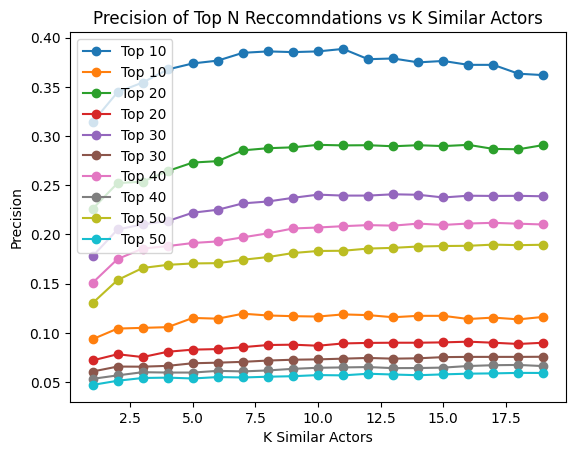

In [65]:
s = scores.groupby(['K_Reccomendations', 'K_SimilarActors'])[['Precision(Train)', 'Precision(Test)']].mean()

for i in np.arange(10,51,10):
    plt.plot(s.loc[i], label=f'Top {i}', marker='o')
plt.title('Precision of Top N Reccomndations vs K Similar Actors')
plt.xlabel('K Similar Actors')
plt.ylabel('Precision')
plt.legend()

del s
plt.show()

The more reccomendations we make, the weaker precision becomes.

The best performing was a Top 10 Reccomendation for Train and Test.

Thre's also a visibile `elbow` where improvements to Precision die off.

In most cases it's around K_Similar_Actors = 2 to 5.

Surprisingly adding less similar actors doesn't weaken reccomendations except for Top10 Recommendation Train.

## Let's Evaluate on Test

### Still Poor Precision <= 0.25
Let's see if a Model can perform better or help fit the sparse data.

# SVD

In [66]:
svd = TruncatedSVD(n_components=500)

U = svd.fit_transform(df_PerformanceScoring)  
Sigma = np.diag(svd.singular_values_)  
Vt = svd.components_  

Y = np.dot(U, np.dot(Sigma, Vt))

print(root_mean_squared_error(df_PerformanceScoring, Y))
del Y

2.0915358619325017


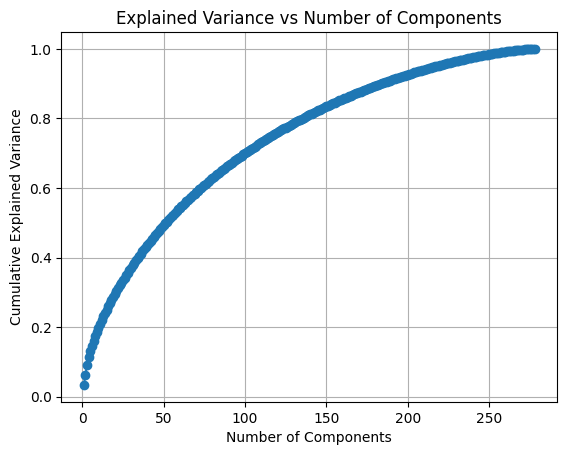

In [67]:
explained_variance = np.cumsum(svd.explained_variance_ratio_)

plt.plot(range(1, len(explained_variance) + 1), explained_variance, marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance vs Number of Components')
plt.grid(True)
plt.show()

### Try aiming for ~80%
150 Components

In [68]:
svd = TruncatedSVD(n_components=150)

U = svd.fit_transform(df_PerformanceScoring.T)  
Sigma = np.diag(svd.singular_values_)  
Vt = svd.components_  

SVD_UserItem = np.dot(U, np.dot(Sigma, Vt))

print('Train RMSE:\t', root_mean_squared_error(df_PerformanceScoring.T, SVD_UserItem))

X_test = pd.read_pickle(MATRICES_FOLDER+'X_test_100roles.pkl')
X_test = pd.pivot_table(X_test, columns='Anime_ID', index='Personnel_ID', values='STD_Character_Favorites', aggfunc='mean').fillna(0)

U = svd.transform(X_test.T)  
Sigma = np.diag(svd.singular_values_)  
Vt = svd.components_  

SVD_UserItemTest = np.dot(U, np.dot(Sigma, Vt))

print('Test RMSE:\t', root_mean_squared_error(X_test.T, SVD_UserItemTest))

Train RMSE:	 3.378909990710855
Test RMSE:	 1.60006310350709


In [69]:
df_PerformanceScoring = pd.DataFrame(SVD_UserItem.T, index=df_PerformanceScoring.index, columns=df_PerformanceScoring.columns)
df_Collabs = pd.DataFrame(cosine_similarity(df_PerformanceScoring), index=df_PerformanceScoring.index, columns=df_PerformanceScoring.index)
df_Collabs.head(10)

Personnel_ID,1,2,3,4,5,6,8,9,10,11,...,33051,33995,34209,34785,34855,36888,36895,38428,38659,42373
Personnel_ID,,,,,,,,,,,,,,,,,,,,,
1,1.000000,-0.012336,-0.011209,0.008669,-0.037892,0.073136,0.015591,0.007440,0.008805,0.075816,...,0.023588,0.067356,0.034141,0.036825,0.073642,-0.009154,-0.022636,0.055150,-0.005160,0.035749
2,-0.012336,1.000000,-0.055199,-0.009007,0.025407,0.047812,0.014989,0.538767,0.652019,0.006900,...,0.606555,0.017868,0.081900,0.038046,0.016331,0.035467,0.032240,0.015244,-0.001418,0.553430
3,-0.011209,-0.055199,1.000000,0.034220,-0.037591,-0.009019,-0.000079,0.015059,0.040027,0.111701,...,0.059154,0.003712,-0.050521,0.039111,-0.165933,-0.013931,-0.022136,-0.002356,-0.000672,0.039983
4,0.008669,-0.009007,0.034220,1.000000,-0.013497,-0.000584,0.028735,0.006443,-0.005007,0.030089,...,0.011652,0.010059,0.031255,-0.005329,0.009124,0.022985,0.009046,0.006921,-0.003473,-0.003959
5,-0.037892,0.025407,-0.037591,-0.013497,1.000000,0.025135,0.032988,0.095785,0.015181,0.001939,...,0.013409,0.013441,-0.016990,0.064898,0.017415,0.033447,0.013767,0.011334,-0.002397,0.021702
6,0.073136,0.047812,-0.009019,-0.000584,0.025135,1.000000,0.314686,0.011214,0.001314,0.308494,...,0.029369,0.760041,0.038836,0.019528,0.589066,0.002902,-0.002503,0.770494,0.001236,0.034837
8,0.015591,0.014989,-0.000079,0.028735,0.032988,0.314686,1.000000,0.005905,0.010916,0.112819,...,0.011011,0.312262,0.102566,0.004266,0.242863,-0.004148,0.000227,0.316211,-0.001668,0.025714
9,0.007440,0.538767,0.015059,0.006443,0.095785,0.011214,0.005905,1.000000,0.646903,0.003645,...,0.844438,0.021915,0.016766,0.010539,0.028308,0.066745,0.035643,0.018230,-0.003149,0.790885
10,0.008805,0.652019,0.040027,-0.005007,0.015181,0.001314,0.010916,0.646903,1.000000,0.010236,...,0.744771,0.016287,-0.049634,-0.013244,0.029135,0.025357,0.049437,0.024119,0.002301,0.687906


In [70]:
# scores = []
# for ACTOR in df_Collabs.index:
#     for K_ACTORS in np.arange(1, 20):
#         for K_REC in np.arange(10,51,10):
#             scores.append(EvaluateScores(ACTOR,K_ACTORS,K_REC))
# scores = pd.DataFrame(scores)
# scores.to_csv('Scores/UserUserSVDPrecision.csv')

scores = pd.read_csv('Scores/UserUserSVDPrecision150.csv')

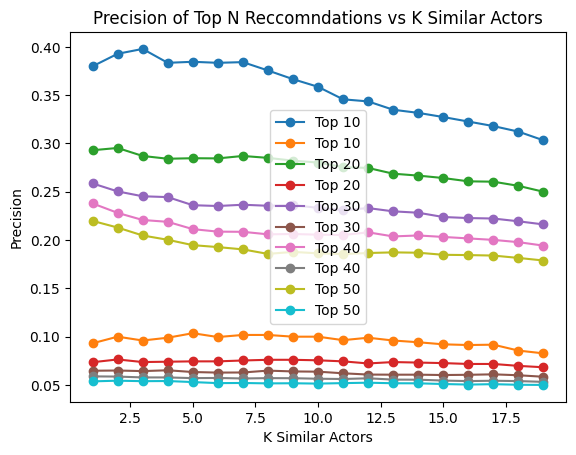

In [71]:
s = scores.groupby(['K_Reccomendations', 'K_SimilarActors'])[['Precision(Train)', 'Precision(Test)']].mean()

for i in np.arange(10,51,10):
    plt.plot(s.loc[i], label=f'Top {i}', marker='o')
plt.title('Precision of Top N Reccomndations vs K Similar Actors')
plt.xlabel('K Similar Actors')
plt.ylabel('Precision')
plt.legend()

plt.show()
del s
del svd

### Discussion
Unfortunaely the Precision seems to worsen and nosedive.

This may be because we are creating artifical data on a supposed to be sparse field.

A show/movie will have only X amount of cast members. With our masking, we hid some of the true answers hoowever because Matrix Factorization will try to impute our previous 0's. 

It's most likely that it can indeed reccomend other similar actos but not the hidden ones.